In [ ]:
pip install seaborn librosa tensorflow

In [ ]:
import os
import random
import numpy as np
import pandas as pd

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Define dataset path
BASE_PATH = "Baby Crying Sounds"

# Check if dataset exists
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"Dataset path '{BASE_PATH}' not found. Please verify the directory.")

# Walk through dataset and list only .wav files
audio_files = []
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith('.wav'):
            audio_files.append(os.path.join(root, file))

# Print summary instead of all paths
print(f"✅ Found {len(audio_files)} audio files in total.")
print("Example file paths:")
for f in audio_files[:5]:
    print(" -", f)


In [ ]:
import os
import random
import numpy as np
import pandas as pd

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Define dataset path
BASE_PATH = "Baby Crying Sounds"

# Check if dataset exists
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"Dataset path '{BASE_PATH}' not found. Please verify the directory.")

# Walk through dataset and list only .wav files
audio_files = []
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith('.wav'):
            audio_files.append(os.path.join(root, file))

# Print summary instead of all paths
print(f"✅ Found {len(audio_files)} audio files in total.")
print("Example file paths:")
for f in audio_files[:5]:
    print(" -", f)


In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
from scipy.signal import butter, sosfilt

# -------------------------
# Paths
# -------------------------
ORIGINAL_DATA_DIR = "Baby Crying Sounds"   # your raw dataset
CLEANED_DATA_DIR = "Cleaned_dataset"       # output directory

os.makedirs(CLEANED_DATA_DIR, exist_ok=True)

# -------------------------
# Stable Bandpass filter (SOS)
# -------------------------
def butter_bandpass(lowcut, highcut, sr, order=5):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = min(highcut / nyq, 0.99)
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos

def bandpass_filter(data, lowcut, highcut, sr, order=5):
    sos = butter_bandpass(lowcut, highcut, sr, order=order)
    return sosfilt(sos, data)

# -------------------------
# Supported audio formats
# -------------------------
AUDIO_EXTENSIONS = ('.wav', '.mp3', '.ogg', '.flac', '.m4a')

# -------------------------
# Process all audio files
# -------------------------
total_files = 0
skipped_files = 0

for class_name in os.listdir(ORIGINAL_DATA_DIR):
    class_dir = os.path.join(ORIGINAL_DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    save_dir = os.path.join(CLEANED_DATA_DIR, class_name)
    os.makedirs(save_dir, exist_ok=True)

    for file in os.listdir(class_dir):
        if not file.lower().endswith(AUDIO_EXTENSIONS):
            continue

        file_path = os.path.join(class_dir, file)
        try:
            # Load audio (librosa handles multiple formats)
            y, sr = librosa.load(file_path, sr=None, mono=True)

            # Apply bandpass filter (200 Hz – 4000 Hz)
            y_filtered = bandpass_filter(y, lowcut=200, highcut=4000, sr=sr, order=6)

            # Normalize amplitude
            maxv = np.max(np.abs(y_filtered))
            if maxv > 0:
                y_filtered = y_filtered / maxv

            # Save as WAV for consistency
            file_base = os.path.splitext(file)[0]
            save_path = os.path.join(save_dir, file_base + ".wav")
            sf.write(save_path, y_filtered, sr)
            total_files += 1

        except Exception as e:
            print(f"⚠️ Skipping file {file_path}: {e}")
            skipped_files += 1
            continue

print(f"✅ Cleaning complete — {total_files} files processed successfully.")
if skipped_files > 0:
    print(f"⚠️ {skipped_files} files were skipped due to errors.")
print(f"Cleaned dataset saved in: '{CLEANED_DATA_DIR}'")


In [ ]:
import os
import librosa
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Suppress only expected warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

# -------------------------
# Settings
# -------------------------
DATA_DIR = "Cleaned_dataset"
OUTPUT_DIR = "Unified_sample_rate"
TARGET_SR = 16000
AUDIO_EXTENSIONS = ('.wav', '.mp3', '.flac', '.ogg', '.m4a')

print(f"--- Starting Resampling Process ---")
print(f"Input Directory: {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Target Sampling Rate: {TARGET_SR} Hz")

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Input directory not found: {DATA_DIR}")

overall_processed_files = 0
overall_error_files = 0
class_summary = {}

for class_name in sorted(os.listdir(DATA_DIR)):
    source_class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(source_class_path):
        continue

    output_class_path = os.path.join(OUTPUT_DIR, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    class_processed_count = 0
    class_error_count = 0
    class_already_correct_sr_count = 0

    for filename in os.listdir(source_class_path):
        source_file_path = os.path.join(source_class_path, filename)
        if not os.path.isfile(source_file_path) or not filename.lower().endswith(AUDIO_EXTENSIONS):
            continue

        output_filename = os.path.splitext(filename)[0] + ".wav"
        output_file_path = os.path.join(output_class_path, output_filename)

        try:
            y, sr_orig = librosa.load(source_file_path, sr=None, mono=True)

            if sr_orig != TARGET_SR:
                # Ensure float32 dtype for librosa.resample
                y = y.astype(np.float32)
                y_resampled = librosa.resample(y, orig_sr=sr_orig, target_sr=TARGET_SR)
            else:
                y_resampled = y
                class_already_correct_sr_count += 1

            # Save as WAV
            sf.write(output_file_path, y_resampled, TARGET_SR)
            class_processed_count += 1

        except Exception as e:
            class_error_count += 1
            print(f"⚠️ Skipping {filename}: {e}")
            continue

    class_summary[class_name] = {
        'processed': class_processed_count,
        'errors': class_error_count,
        'already_target_sr': class_already_correct_sr_count
    }

    overall_processed_files += class_processed_count
    overall_error_files += class_error_count

# -------------------------
# Summary
# -------------------------
print("\n--- Resampling Summary ---")
for class_name_key, summary in class_summary.items():
    print(f"Class '{class_name_key}':")
    print(f"  - Processed and saved: {summary['processed']} files.")
    if summary['already_target_sr'] > 0:
        print(f"    ({summary['already_target_sr']} files already at {TARGET_SR} Hz)")
    if summary['errors'] > 0:
        print(f"  - Files with errors: {summary['errors']}")
    print("-" * 30)

print(f"\nOverall processed: {overall_processed_files} files")
print(f"Overall errors: {overall_error_files}")
print(f"Resampled files saved to: {OUTPUT_DIR}")

# -------------------------
# Verification & Visualization
# -------------------------
print("\n--- Verifying Sample Rates ---")
output_files_sr_info = []

for class_name_out in sorted(os.listdir(OUTPUT_DIR)):
    class_path_out = os.path.join(OUTPUT_DIR, class_name_out)
    if not os.path.isdir(class_path_out):
        continue

    for filename_out in os.listdir(class_path_out):
        file_path_out = os.path.join(class_path_out, filename_out)
        if os.path.isfile(file_path_out) and filename_out.lower().endswith('.wav'):
            try:
                info = sf.info(file_path_out)
                output_files_sr_info.append({'sample_rate_hz': info.samplerate})
            except Exception as e:
                print(f"⚠️ Could not read SR for {file_path_out}: {e}")

if output_files_sr_info:
    df_output_sr = pd.DataFrame(output_files_sr_info)
    sr_counts_output = df_output_sr['sample_rate_hz'].value_counts()

    print("\nSample Rate Distribution:")
    print(sr_counts_output)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=sr_counts_output.index.astype(str), y=sr_counts_output.values, palette='pastel')
    plt.title(f'Sample Rate Distribution (Target: {TARGET_SR} Hz)')
    plt.xlabel('Sample Rate (Hz)')
    plt.ylabel('Number of Files')

    for i, count_val in enumerate(sr_counts_output.values):
        plt.text(i, count_val + (0.01 * sr_counts_output.values.max()), str(count_val),
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    if len(sr_counts_output) == 1 and sr_counts_output.index[0] == TARGET_SR:
        print(f"\n✅ SUCCESS: All {len(df_output_sr)} files are at {TARGET_SR} Hz.")
    else:
        print(f"\n⚠️ WARNING: Some files are not at the target sample rate.")
else:
    print("⚠️ No sample rate data found for verification.")

print("\n--- Resampling Script Finished ---")


In [ ]:
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Configuration
# -----------------------------
PROCESSED_DATA_DIR = "Unified_sample_rate"  # Directory containing resampled mono files
EXPECTED_CHANNELS = 1                       # Expected number of channels (mono)

print(f"--- Analyzing Audio Channel Data from: {PROCESSED_DATA_DIR} ---")

# -----------------------------
# Data Collection
# -----------------------------
channel_info_list = []

if not os.path.isdir(PROCESSED_DATA_DIR):
    print(f"❌ ERROR: Directory not found: {PROCESSED_DATA_DIR}")
else:
    for class_name in sorted(os.listdir(PROCESSED_DATA_DIR)):
        class_path = os.path.join(PROCESSED_DATA_DIR, class_name)
        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            # Check for valid audio extensions
            if not os.path.isfile(file_path) or not filename.lower().endswith(('.wav', '.flac', '.ogg', '.mp3', '.m4a')):
                continue

            try:
                # Load without forcing mono, to detect channel count
                y, sr = librosa.load(file_path, sr=None, mono=False)

                num_channels = 1 if y.ndim == 1 else y.shape[0]

                channel_info_list.append({
                    'class': class_name,
                    'filename': filename,
                    'channels': num_channels
                })

            except Exception as e:
                print(f"⚠️ Could not analyze channels for {file_path}: {e}")

# -----------------------------
# Analysis and Visualization
# -----------------------------
if not channel_info_list:
    print("⚠️ No processed audio files found or failed to analyze channels.")
else:
    df_channels = pd.DataFrame(channel_info_list)
    print(f"\n✅ Successfully analyzed channels for {len(df_channels)} processed files.")

    # Distribution of audio channels
    print("\n1️⃣ Distribution of Audio Channels in Processed Files:")
    channel_counts = df_channels['channels'].value_counts().sort_index()
    print(channel_counts)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(x=channel_counts.index.astype(str), y=channel_counts.values, palette='coolwarm')
    plt.title(f'Audio Channel Distribution\n(Expected: {EXPECTED_CHANNELS} channel = mono)')
    plt.xlabel('Number of Channels')
    plt.ylabel('Number of Files')

    for i, count in enumerate(channel_counts.values):
        plt.text(i, count + (0.02 * channel_counts.values.max()), str(count), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Check mono conformity
    if len(channel_counts) == 1 and channel_counts.index[0] == EXPECTED_CHANNELS:
        print(f"\n🎯 SUCCESS: All {len(df_channels)} processed files are mono ({EXPECTED_CHANNELS} channel).")
    else:
        print(f"\nℹ️ INFO: Some files may not be mono. Review the distribution above.")
        non_mono_files = df_channels[df_channels['channels'] != EXPECTED_CHANNELS]
        if not non_mono_files.empty:
            print(f"  ⚠️ Found {len(non_mono_files)} files that are not mono:")
            print(non_mono_files.head())

print("\n--- Channel Analysis Script Finished ---")


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
INPUT_UNIFIED_SR_MONO_DIR = "Unified_sample_rate"
OUTPUT_UNIFIED_DURATION_DIR = "Unified_duration_7S"
TARGET_DURATION_SEC = 7.0
TARGET_SR = 16000 

print(f"--- Starting Duration Unification Process ---")
print(f"Input Directory (16kHz, Mono): {INPUT_UNIFIED_SR_MONO_DIR}")
print(f"Output Directory (Unified Duration): {OUTPUT_UNIFIED_DURATION_DIR}")
print(f"Target Duration: {TARGET_DURATION_SEC} seconds")
print(f"Using Sample Rate: {TARGET_SR} Hz for calculations")

os.makedirs(OUTPUT_UNIFIED_DURATION_DIR, exist_ok=True)

if not os.path.isdir(INPUT_UNIFIED_SR_MONO_DIR):
    raise FileNotFoundError(f"Input directory '{INPUT_UNIFIED_SR_MONO_DIR}' not found.")

overall_processed_files = 0
overall_error_files = 0
duration_summary_per_class = {}

target_length_samples = int(TARGET_DURATION_SEC * TARGET_SR)

for class_name in sorted(os.listdir(INPUT_UNIFIED_SR_MONO_DIR)):
    source_class_path = os.path.join(INPUT_UNIFIED_SR_MONO_DIR, class_name)
    if not os.path.isdir(source_class_path):
        continue

    output_class_path = os.path.join(OUTPUT_UNIFIED_DURATION_DIR, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    class_processed_count = 0
    class_error_count = 0
    class_padded_count = 0
    class_truncated_count = 0
    class_exact_match_count = 0

    print(f"\nProcessing class: '{class_name}'...")

    for filename in os.listdir(source_class_path):
        if not filename.lower().endswith('.wav'):
            continue

        source_file_path = os.path.join(source_class_path, filename)
        output_file_path = os.path.join(output_class_path, filename)

        try:
            y, sr = librosa.load(source_file_path, sr=TARGET_SR, mono=True)
            current_length_samples = len(y)
            processed_y = y

            if current_length_samples < target_length_samples:
                padding_needed = target_length_samples - current_length_samples
                processed_y = np.pad(y, (0, padding_needed), mode='constant', constant_values=0)
                class_padded_count += 1
            elif current_length_samples > target_length_samples:
                processed_y = y[:target_length_samples]
                class_truncated_count += 1
            else:
                class_exact_match_count += 1

            sf.write(output_file_path, processed_y, TARGET_SR)
            class_processed_count += 1

        except Exception as e:
            print(f"ERROR processing file '{filename}': {e}")
            class_error_count += 1

    duration_summary_per_class[class_name] = {
        'processed': class_processed_count,
        'errors': class_error_count,
        'padded': class_padded_count,
        'truncated': class_truncated_count,
        'exact_match': class_exact_match_count
    }

    overall_processed_files += class_processed_count
    overall_error_files += class_error_count

    print(f"  Class '{class_name}': Processed={class_processed_count}, "
          f"Padded={class_padded_count}, Truncated={class_truncated_count}, "
          f"Exact={class_exact_match_count}, Errors={class_error_count}")

print("\n--- Duration Unification Summary ---")
print(f"Overall Total audio files processed and saved: {overall_processed_files}")
print(f"Overall Total files with errors: {overall_error_files}")
print(f"Files with unified duration ({TARGET_DURATION_SEC}s) are saved in: {OUTPUT_UNIFIED_DURATION_DIR}")

# --- Verify durations ---
if overall_processed_files > 0:
    output_files_duration_info = []
    for class_name_out in sorted(os.listdir(OUTPUT_UNIFIED_DURATION_DIR)):
        class_path_out = os.path.join(OUTPUT_UNIFIED_DURATION_DIR, class_name_out)
        if not os.path.isdir(class_path_out):
            continue
        for filename_out in os.listdir(class_path_out):
            if not filename_out.lower().endswith('.wav'):
                continue
            file_path_out = os.path.join(class_path_out, filename_out)
            try:
                y_out, sr_out = librosa.load(file_path_out, sr=TARGET_SR, mono=True)
                duration_out = len(y_out) / TARGET_SR
                output_files_duration_info.append({'duration_sec': duration_out})
            except Exception as e:
                print(f"  Could not get duration from output file {file_path_out}: {e}")

    if output_files_duration_info:
        df_output_duration = pd.DataFrame(output_files_duration_info)
        print("\nDuration Statistics of files in Output Directory (seconds):")
        print(df_output_duration['duration_sec'].describe().round(3))

        plt.figure(figsize=(10, 6))
        sns.histplot(data=df_output_duration, x='duration_sec', bins=30, kde=False)
        plt.title(f'Distribution of Audio Durations in Output Directory\n(Target: {TARGET_DURATION_SEC:.1f} s)')
        plt.xlabel('Duration (seconds)')
        plt.ylabel('Number of Files')
        plt.axvline(TARGET_DURATION_SEC, color='r', linestyle='--', label=f'Target: {TARGET_DURATION_SEC:.1f}s')
        plt.legend()
        plt.tight_layout()
        plt.show()

        tolerance = 0.001
        all_durations_correct = all(abs(d - TARGET_DURATION_SEC) < tolerance for d in df_output_duration['duration_sec'])

        if all_durations_correct:
            print(f"\nSUCCESS: All {len(df_output_duration)} processed files have duration very close to {TARGET_DURATION_SEC:.1f} seconds.")
        else:
            print(f"\nWARNING: Some files have durations outside the tolerance.")
            problematic_durations = df_output_duration[abs(df_output_duration['duration_sec'] - TARGET_DURATION_SEC) >= tolerance]
            if not problematic_durations.empty:
                print(f"  Found {len(problematic_durations)} problematic files (showing first 5):")
                print(problematic_durations.head())

print("\n--- Duration Unification Script Finished ---")


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
PROCESSED_DATA_DIR = "Unified_duration_7S"
KNOWN_SR = 16000

print(f"--- Analyzing Audio Energy by Class from: {PROCESSED_DATA_DIR} ---")
print(f"--- Assuming audio files are at {KNOWN_SR} Hz and Mono ---")

energy_info_list = []

if not os.path.isdir(PROCESSED_DATA_DIR):
    print(f"ERROR: Directory not found: {PROCESSED_DATA_DIR}")
else:
    for class_name in sorted(os.listdir(PROCESSED_DATA_DIR)):
        class_path = os.path.join(PROCESSED_DATA_DIR, class_name)
        if not os.path.isdir(class_path):
            continue

        print(f"Processing class for energy analysis: '{class_name}'...")

        wav_files = [f for f in os.listdir(class_path) if f.lower().endswith('.wav')]
        if not wav_files:
            print(f"  No WAV files found in class '{class_name}', skipping.")
            continue

        for filename in wav_files:
            file_path = os.path.join(class_path, filename)
            try:
                y, sr = librosa.load(file_path, sr=KNOWN_SR, mono=True)
                rms_energy = np.sqrt(np.mean(y**2)) if len(y) > 0 else 0.0

                energy_info_list.append({
                    'class': class_name,
                    'filename': filename,
                    'rms_energy': rms_energy,
                    'path': file_path
                })
            except Exception as e:
                print(f"  Could not load/analyze energy for {file_path}: {e}")

if not energy_info_list:
    print("No processed audio files found or could not analyze their energy.")
else:
    df_energy = pd.DataFrame(energy_info_list)
    print(f"\nSuccessfully analyzed energy for {len(df_energy)} processed files.")

    # --- Overall statistics ---
    print("\n1. Overall RMS Energy Statistics:")
    print(df_energy['rms_energy'].describe().round(5))

    # --- Per class statistics ---
    print("\n2. RMS Energy Statistics per Class:")
    energy_stats_per_class = df_energy.groupby('class')['rms_energy'].describe().round(5)
    print(energy_stats_per_class)

    # --- Boxplot per class ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_energy, x='rms_energy', y='class', palette='viridis', showfliers=True)
    plt.title('Distribution of RMS Energy per Class')
    plt.xlabel('RMS Energy')
    plt.ylabel('Class')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Violin plot per class ---
    plt.figure(figsize=(12, 7))
    sns.violinplot(data=df_energy, x='rms_energy', y='class', palette='magma', inner='quartile')
    plt.title('Density of RMS Energy per Class (Violin Plot)')
    plt.xlabel('RMS Energy')
    plt.ylabel('Class')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Overall distribution histogram ---
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_energy, x='rms_energy', bins=50, kde=True)
    plt.title('Overall Distribution of RMS Energy')
    plt.xlabel('RMS Energy')
    plt.ylabel('Number of Files')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Identify extreme energy files ---
    print("\n3. Files with Potentially Low or High Energy (based on RMS):")

    low_energy_threshold = df_energy['rms_energy'].quantile(0.01)
    high_energy_threshold = df_energy['rms_energy'].quantile(0.99)

    # Low energy files
    print(f"Low energy threshold (bottom 1%): {low_energy_threshold:.5f}")
    bottom_energy_files = df_energy[df_energy['rms_energy'] <= low_energy_threshold].sort_values(by='rms_energy')
    if not bottom_energy_files.empty:
        print(f"Found {len(bottom_energy_files)} files with RMS energy <= {low_energy_threshold:.5f} (showing up to 5):")
        print(bottom_energy_files[['class', 'filename', 'rms_energy']].head())
    else:
        print(f"No files found with RMS energy <= {low_energy_threshold:.5f}.")

    # High energy files
    print(f"\nHigh energy threshold (top 1%): {high_energy_threshold:.5f}")
    top_energy_files = df_energy[df_energy['rms_energy'] >= high_energy_threshold].sort_values(by='rms_energy', ascending=False)
    if not top_energy_files.empty:
        print(f"Found {len(top_energy_files)} files with RMS energy >= {high_energy_threshold:.5f} (showing up to 5):")
        print(top_energy_files[['class', 'filename', 'rms_energy']].head())
    else:
        print(f"No files found with RMS energy >= {high_energy_threshold:.5f}.")

print("\n--- Energy Analysis Script Finished ---")


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
INPUT_UNIFIED_ALL_DIR = "Unified_duration_7S"
OUTPUT_NORMALIZED_DIR = "Normalized_peak_audio"
KNOWN_SR = 16000

print(f"--- Starting Peak Normalization Process ---")
print(f"Input Directory (Unified SR, Mono, Duration): {INPUT_UNIFIED_ALL_DIR}")
print(f"Output Directory (Peak Normalized Audio): {OUTPUT_NORMALIZED_DIR}")
print(f"Using Sample Rate: {KNOWN_SR} Hz for loading")

os.makedirs(OUTPUT_NORMALIZED_DIR, exist_ok=True)

if not os.path.isdir(INPUT_UNIFIED_ALL_DIR):
    raise FileNotFoundError(f"CRITICAL ERROR: Input directory '{INPUT_UNIFIED_ALL_DIR}' not found.")

overall_processed_files = 0
overall_error_files = 0
normalization_summary_per_class = {}

for class_name in sorted(os.listdir(INPUT_UNIFIED_ALL_DIR)):
    source_class_path = os.path.join(INPUT_UNIFIED_ALL_DIR, class_name)
    if not os.path.isdir(source_class_path):
        continue

    output_class_path = os.path.join(OUTPUT_NORMALIZED_DIR, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    class_processed_count = 0
    class_error_count = 0
    class_skipped_silence_count = 0

    print(f"\nProcessing class for Peak Normalization: '{class_name}'...")

    wav_files = [f for f in os.listdir(source_class_path) if f.lower().endswith('.wav')]
    if not wav_files:
        print(f"  No WAV files found in class '{class_name}', skipping.")
        continue

    for filename in wav_files:
        source_file_path = os.path.join(source_class_path, filename)
        output_file_path = os.path.join(output_class_path, filename)

        try:
            y, sr = librosa.load(source_file_path, sr=KNOWN_SR, mono=True)

            if y.size == 0:
                print(f"  Skipping empty audio file: {filename}")
                class_skipped_silence_count += 1
                continue

            peak_value = np.max(np.abs(y))

            if peak_value > 1e-6:  # Avoid division by zero for near-silence
                y_normalized = y / peak_value
            else:
                y_normalized = y
                class_skipped_silence_count += 1

            sf.write(output_file_path, y_normalized, KNOWN_SR)
            class_processed_count += 1

        except Exception as e:
            print(f"ERROR processing file '{filename}': {e}")
            class_error_count += 1

    normalization_summary_per_class[class_name] = {
        'processed': class_processed_count,
        'errors': class_error_count,
        'skipped_due_to_silence': class_skipped_silence_count
    }

    overall_processed_files += class_processed_count
    overall_error_files += class_error_count

    print(f"  Class '{class_name}': Processed={class_processed_count}, "
          f"Skipped (silence)={class_skipped_silence_count}, Errors={class_error_count}")

# --- Summary ---
print("\n--- Peak Normalization Summary ---")
print(f"Overall Total audio files processed and saved: {overall_processed_files}")
print(f"Overall Total files with errors: {overall_error_files}")

total_skipped_silence = sum(s['skipped_due_to_silence'] for s in normalization_summary_per_class.values())
if total_skipped_silence > 0:
    print(f"Total files skipped for normalization due to near-silence: {total_skipped_silence}")

print(f"Peak Normalized files are saved in: {OUTPUT_NORMALIZED_DIR}")
print("\n--- Peak Normalization Script Finished ---")


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DIR_BEFORE_NORMALIZATION = "Unified_duration_7S"
DIR_AFTER_NORMALIZATION = "Normalized_peak_audio"
KNOWN_SR = 16000

print(f"--- Comparing RMS Energy Before and After Peak Normalization ---")

def get_energy_data(data_dir, label):
    energy_info = []
    if not os.path.isdir(data_dir):
        print(f"ERROR: Directory not found: {data_dir}")
        return pd.DataFrame() 

    print(f"Processing directory for '{label}': {data_dir}")
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        wav_files = [f for f in os.listdir(class_path) if f.lower().endswith('.wav')]
        if not wav_files:
            continue

        for filename in wav_files:
            file_path = os.path.join(class_path, filename)
            try:
                y, sr = librosa.load(file_path, sr=KNOWN_SR, mono=True)
                rms_energy = np.sqrt(np.mean(y**2)) if len(y) > 0 else 0.0
                energy_info.append({
                    'class': class_name,
                    'filename': filename,
                    'rms_energy': rms_energy,
                    'condition': label 
                })
            except Exception as e:
                print(f"Could not process {file_path} for '{label}': {e}")
    return pd.DataFrame(energy_info)

# --- Collect energy data ---
df_before = get_energy_data(DIR_BEFORE_NORMALIZATION, "Before Normalization")
df_after = get_energy_data(DIR_AFTER_NORMALIZATION, "After Normalization")

if df_before.empty or df_after.empty:
    print("Could not collect sufficient data for comparison.")
else:
    df_combined = pd.concat([df_before, df_after], ignore_index=True)
    print(f"\nCollected data: {len(df_before)} files before, {len(df_after)} files after normalization.")

    # --- RMS statistics ---
    print("\n--- RMS Energy Statistics ---")
    print("\nBefore Peak Normalization:")
    print(df_before['rms_energy'].describe().round(5))
    print("\nAfter Peak Normalization:")
    print(df_after['rms_energy'].describe().round(5))

    epsilon = 1e-9  # avoid log(0)

    # --- Boxplot per class ---
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df_combined, x='rms_energy', y='class', hue='condition', palette={'Before Normalization':'skyblue', 'After Normalization':'lightcoral'}, showfliers=True)
    plt.title('RMS Energy Distribution per Class: Before vs. After Peak Normalization')
    plt.xlabel('RMS Energy')
    plt.ylabel('Class')
    plt.xscale('log')
    plt.legend(title='Condition')
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Violin plot per class ---
    plt.figure(figsize=(14, 8))
    hue_levels = df_combined['condition'].unique()
    split_violin = True if len(hue_levels) == 2 else False

    sns.violinplot(
        data=df_combined,
        x='rms_energy',
        y='class',
        hue='condition',
        palette={'Before Normalization':'skyblue', 'After Normalization':'lightcoral'},
        inner='quartile',
        split=split_violin
    )
    plt.title('RMS Energy Density per Class: Before vs. After Peak Normalization')
    plt.xlabel('RMS Energy')
    plt.ylabel('Class')
    plt.xscale('log')
    plt.legend(title='Condition', loc='lower right')
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Overall histogram ---
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_before, x='rms_energy'+epsilon, color="skyblue", label='Before Normalization', kde=True, stat="density", element="step", fill=False)
    sns.histplot(data=df_after, x='rms_energy'+epsilon, color="lightcoral", label='After Normalization', kde=True, stat="density", element="step", fill=False)
    plt.title('Overall RMS Energy Distribution: Before vs. After Peak Normalization')
    plt.xlabel('RMS Energy')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\n--- Energy Comparison Script Finished ---")


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# --- Configuration ---
INPUT_NORMALIZED_AUDIO_DIR = "Normalized_peak_audio"
OUTPUT_AUGMENTED_DIR = "Augmented_audio_550"
TARGET_SAMPLES_PER_CLASS = 550
KNOWN_SR = 16000

NOISE_FACTOR_RANGE = (0.001, 0.005)
TIME_STRETCH_RATE_RANGE = (0.85, 1.15)
PITCH_SHIFT_STEPS_RANGE = (-2, 2)
TIME_SHIFT_MAX_SEC = 0.2
TARGET_DURATION_SEC = 7.0
target_length_samples = int(TARGET_DURATION_SEC * KNOWN_SR)

# --- Augmentation Functions ---
def add_noise(y, noise_factor_range):
    noise_factor = random.uniform(*noise_factor_range)
    noise = np.random.randn(len(y))
    return np.clip(y + noise_factor * noise, -1.0, 1.0)

def time_stretch_audio(y, sr, stretch_rate_range):
    rate = random.uniform(*stretch_rate_range)
    while rate == 1.0:
        rate = random.uniform(*stretch_rate_range)
    return librosa.effects.time_stretch(y, rate)

def pitch_shift_audio(y, sr, pitch_steps_range):
    n_steps = random.uniform(*pitch_steps_range)
    while n_steps == 0.0:
        n_steps = random.uniform(*pitch_steps_range)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_shift_audio(y, sr, max_shift_sec):
    shift_samples = int(random.uniform(-max_shift_sec, max_shift_sec) * sr)
    if shift_samples == 0:
        min_abs_shift = max(1, int(0.01 * sr))
        shift_samples = random.choice([-min_abs_shift, min_abs_shift])
    y_aug = np.roll(y, shift_samples)
    if shift_samples > 0:
        y_aug[:shift_samples] = 0
    else:
        y_aug[shift_samples:] = 0
    return y_aug

augmentation_functions = [add_noise, time_stretch_audio, pitch_shift_audio, time_shift_audio]

def adjust_length(y, target_len):
    if len(y) < target_len:
        return np.pad(y, (0, target_len - len(y)), mode='constant')
    return y[:target_len]

# --- Start Augmentation ---
print(f"--- Starting Data Augmentation Process ---")
print(f"Input Directory: {INPUT_NORMALIZED_AUDIO_DIR}")
print(f"Output Directory: {OUTPUT_AUGMENTED_DIR}")
print(f"Target Samples per Class: {TARGET_SAMPLES_PER_CLASS}")

os.makedirs(OUTPUT_AUGMENTED_DIR, exist_ok=True)

if not os.path.isdir(INPUT_NORMALIZED_AUDIO_DIR):
    raise FileNotFoundError(f"CRITICAL ERROR: Input directory '{INPUT_NORMALIZED_AUDIO_DIR}' not found.")

overall_original_files_copied = 0
overall_augmented_files_created = 0
overall_errors = 0
final_class_counts = {}

for class_name in sorted(os.listdir(INPUT_NORMALIZED_AUDIO_DIR)):
    source_class_path = os.path.join(INPUT_NORMALIZED_AUDIO_DIR, class_name)
    if not os.path.isdir(source_class_path):
        continue

    output_class_path = os.path.join(OUTPUT_AUGMENTED_DIR, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    print(f"\nAugmenting class: '{class_name}'...")

    original_files = [f for f in os.listdir(source_class_path) if f.lower().endswith('.wav')]
    num_original_files = len(original_files)

    # Copy original files
    for filename in original_files:
        try:
            y, _ = librosa.load(os.path.join(source_class_path, filename), sr=KNOWN_SR, mono=True)
            sf.write(os.path.join(output_class_path, filename), y, KNOWN_SR)
            overall_original_files_copied += 1
        except Exception as e:
            print(f"    ERROR copying original file '{filename}': {e}")
            overall_errors += 1

    num_augmentations_needed = TARGET_SAMPLES_PER_CLASS - num_original_files
    if num_augmentations_needed <= 0:
        print(f"  Class '{class_name}' already has/exceeds {TARGET_SAMPLES_PER_CLASS} samples ({num_original_files} original).")
        final_class_counts[class_name] = num_original_files
        continue

    print(f"  Original files: {num_original_files}. Need to generate {num_augmentations_needed} augmented samples.")
    augmented_count_for_class = 0

    for i in range(num_augmentations_needed):
        if not original_files:
            break
        base_filename = random.choice(original_files)
        augmented_filename = f"aug_{i+1}_{base_filename}"
        try:
            y_base, _ = librosa.load(os.path.join(source_class_path, base_filename), sr=KNOWN_SR, mono=True)
            chosen_func = random.choice(augmentation_functions)
            y_aug = chosen_func(y_base, KNOWN_SR) if chosen_func != add_noise else add_noise(y_base, NOISE_FACTOR_RANGE)
            y_aug = adjust_length(y_aug, target_length_samples)
            peak_val = np.max(np.abs(y_aug))
            if peak_val > 1e-6:
                y_aug = y_aug / peak_val
            sf.write(os.path.join(output_class_path, augmented_filename), y_aug, KNOWN_SR)
            augmented_count_for_class += 1
            overall_augmented_files_created += 1
        except Exception as e:
            print(f"    ERROR augmenting '{augmented_filename}': {e}")
            overall_errors += 1
        if (i+1) % 100 == 0:
            print(f"    Generated {i+1}/{num_augmentations_needed} for '{class_name}'...")

    final_class_counts[class_name] = num_original_files + augmented_count_for_class
    print(f"  Finished '{class_name}'. Total files: {final_class_counts[class_name]} "
          f"(Original: {num_original_files}, Augmented: {augmented_count_for_class}).")

# --- Summary ---
print("\n--- Data Augmentation Summary ---")
print(f"Total original files copied: {overall_original_files_copied}")
print(f"Total new augmented files created: {overall_augmented_files_created}")
print(f"Total errors during augmentation: {overall_errors}")
print(f"Augmented data saved in: {OUTPUT_AUGMENTED_DIR}")

# --- Final Class Distribution Plot ---
if final_class_counts:
    df_final_counts = pd.DataFrame(list(final_class_counts.items()), columns=['class', 'count']).sort_values(by='class')
    plt.figure(figsize=(10, max(5, len(df_final_counts) * 0.5)))
    barplot = sns.barplot(data=df_final_counts, y='class', x='count', palette='viridis')
    plt.title(f'Final File Count per Class after Augmentation (Target: {TARGET_SAMPLES_PER_CLASS})')
    plt.xlabel('Number of Files')
    plt.ylabel('Class')

    # Add counts on bars
    for i, row in enumerate(df_final_counts.itertuples()):
        barplot.text(row.count + 0.01 * df_final_counts['count'].max(), i, str(row.count), color='black', ha='left', va='center')

    plt.axvline(TARGET_SAMPLES_PER_CLASS, color='r', linestyle='--', label=f'Target: {TARGET_SAMPLES_PER_CLASS}')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for final class distribution.")

print("\n--- Data Augmentation Script Finished ---")


--- Starting Enhanced Entropy Feature Extraction ---
Input: Augmented_audio_550
Output: Entropy_features
Parameters: SR=16000, FFT=2048, Hop=512, Frames=219

Processing class: 'belly pain'
  Feature shape: (12, 219) (N_Features, Time_Frames)


C:\Users\91720\AppData\Local\Temp\ipykernel_16424\1084268697.py:40: RuntimeWarning: invalid value encountered in divide
  psd = S / np.sum(S, axis=0, keepdims=True)



Processing class: 'burping'

Processing class: 'cold_hot'

Processing class: 'discomfort'

Processing class: 'hungry'

Processing class: 'tired'

--- Extraction Summary ---
✅ Total features extracted: 3300
⚠️  Errors: 0
Feature shape example: (12, 219)
Features saved in: Entropy_features
Manifest saved: Entropy_features\_manifest_entropy.csv

Visualizing a random sample feature map...


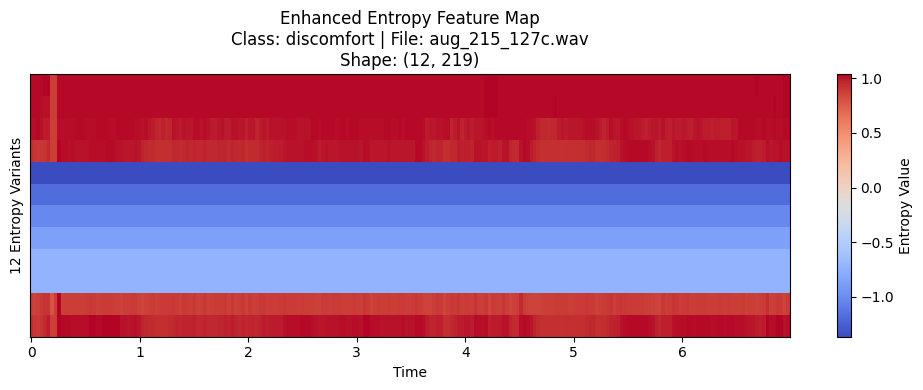


--- Enhanced Entropy Feature Extraction Complete ---


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa.display
import random

# -------------------------------
# Configuration
# -------------------------------
INPUT_AUGMENTED_AUDIO_DIR = "Augmented_audio_550"
OUTPUT_ENTROPY_DIR = "Entropy_features"
KNOWN_SR = 16000
N_FFT = 2048
HOP_LENGTH = 512
FIXED_TIME_FRAMES = 219  # fixed frame length for consistency

print(f"--- Starting Enhanced Entropy Feature Extraction ---")
print(f"Input: {INPUT_AUGMENTED_AUDIO_DIR}")
print(f"Output: {OUTPUT_ENTROPY_DIR}")
print(f"Parameters: SR={KNOWN_SR}, FFT={N_FFT}, Hop={HOP_LENGTH}, Frames={FIXED_TIME_FRAMES}")

os.makedirs(OUTPUT_ENTROPY_DIR, exist_ok=True)

# -------------------------------
# Helper Functions
# -------------------------------
def shannon_entropy(signal, bins=100):
    """Shannon entropy of amplitude distribution."""
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return 0.0
    return -np.sum(hist * np.log2(hist))

def spectral_entropy(y, sr, n_fft=2048, hop_length=512):
    """Spectral entropy per frame (time-based vector)."""
    S = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length))**2
    psd = S / np.sum(S, axis=0, keepdims=True)
    ent = -np.sum(psd * np.log2(psd + 1e-12), axis=0)
    ent = np.nan_to_num(ent)
    return ent

def multi_scale_entropy(signal, max_scale=5):
    """Compute entropy at multiple coarse-grained time scales."""
    entropies = []
    for scale in range(1, max_scale + 1):
        n = len(signal) // scale
        if n == 0:
            entropies.append(0.0)
            continue
        coarse = np.mean(signal[:n * scale].reshape(n, scale), axis=1)
        entropies.append(shannon_entropy(coarse))
    return np.array(entropies)

def bandwise_entropy(y, sr, n_fft=2048, hop_length=512, num_bands=4):
    """Compute spectral entropy within multiple frequency bands."""
    S = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length))**2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    band_edges = np.linspace(0, sr // 2, num_bands + 1)
    entropies = []
    for i in range(num_bands):
        low, high = band_edges[i], band_edges[i + 1]
        idx = np.where((freqs >= low) & (freqs < high))[0]
        psd_band = S[idx, :]
        psd_band /= np.sum(psd_band, axis=0, keepdims=True) + 1e-12
        ent = -np.sum(psd_band * np.log2(psd_band + 1e-12), axis=0)
        ent = np.nan_to_num(ent)
        entropies.append(ent)
    return np.array(entropies)  # shape: (num_bands, frames)


def pad_to_fixed(x):
    if len(x) < FIXED_TIME_FRAMES:
        return np.pad(x, (0, FIXED_TIME_FRAMES - len(x)))
    return x[:FIXED_TIME_FRAMES]

def extract_entropy_features(y, sr, n_fft, hop_length, fixed_frames, max_scale=5):
    """Extract combined entropy-based features."""
    # Frame-wise spectral entropy
    frame_entropy = spectral_entropy(y, sr, n_fft, hop_length)
    delta_entropy = np.diff(frame_entropy, prepend=frame_entropy[0])
    shannon_val = shannon_entropy(y)
    band_entropy = bandwise_entropy(y, sr, n_fft, hop_length)
    mse = multi_scale_entropy(y, max_scale=max_scale)

    # Normalize frame features
    def pad_to_fixed(x):
        if len(x) < fixed_frames:
            return np.pad(x, (0, fixed_frames - len(x)), mode='constant')
        else:
            return x[:fixed_frames]

    frame_entropy = pad_to_fixed(frame_entropy)
    delta_entropy = pad_to_fixed(delta_entropy)
    replicated_shannon = np.ones(fixed_frames) * shannon_val
    mse_tiled = np.tile(mse[:, np.newaxis], (1, fixed_frames))
    band_entropy = np.array([pad_to_fixed(b) for b in band_entropy])

    final_features = np.vstack([
        frame_entropy,
        delta_entropy,
        replicated_shannon,
        mse_tiled,
        band_entropy
    ])

    # Normalize across time dimension
    final_features = np.nan_to_num(final_features)
    final_features = (final_features - np.mean(final_features)) / (np.std(final_features) + 1e-8)

    return final_features

# -------------------------------
# Processing Pipeline
# -------------------------------
if not os.path.isdir(INPUT_AUGMENTED_AUDIO_DIR):
    print(f"ERROR: Input directory '{INPUT_AUGMENTED_AUDIO_DIR}' not found.")
else:
    overall_features_extracted = 0
    overall_errors = 0
    processed_manifest = []
    first_shape = None

    for class_name in sorted(os.listdir(INPUT_AUGMENTED_AUDIO_DIR)):
        source_class_path = os.path.join(INPUT_AUGMENTED_AUDIO_DIR, class_name)
        if not os.path.isdir(source_class_path):
            continue

        output_class_path = os.path.join(OUTPUT_ENTROPY_DIR, class_name)
        os.makedirs(output_class_path, exist_ok=True)

        print(f"\nProcessing class: '{class_name}'")

        for filename in sorted(os.listdir(source_class_path)):
            if not filename.lower().endswith(('.wav', '.ogg', '.mp3')):
                continue

            source_path = os.path.join(source_class_path, filename)
            output_path = os.path.join(output_class_path, f"{os.path.splitext(filename)[0]}_entropy.npy")

            try:
                y, sr = librosa.load(source_path, sr=KNOWN_SR, mono=True)
                target_samples = int(7.0 * KNOWN_SR)
                if len(y) < target_samples:
                    y = np.pad(y, (0, target_samples - len(y)), mode='constant')
                else:
                    y = y[:target_samples]

                features = extract_entropy_features(y, sr, N_FFT, HOP_LENGTH, FIXED_TIME_FRAMES, max_scale=5)
                np.save(output_path, features)
                overall_features_extracted += 1

                if first_shape is None:
                    first_shape = features.shape
                    print(f"  Feature shape: {first_shape} (N_Features, Time_Frames)")

                processed_manifest.append({
                    'class': class_name,
                    'original_file': filename,
                    'feature_path': output_path,
                    'shape': features.shape
                })

            except Exception as e:
                print(f"  ERROR in '{filename}': {e}")
                overall_errors += 1

    print("\n--- Extraction Summary ---")
    print(f"✅ Total features extracted: {overall_features_extracted}")
    print(f"⚠️  Errors: {overall_errors}")
    if first_shape:
        print(f"Feature shape example: {first_shape}")
    print(f"Features saved in: {OUTPUT_ENTROPY_DIR}")

    if processed_manifest:
        df_manifest = pd.DataFrame(processed_manifest)
        manifest_path = os.path.join(OUTPUT_ENTROPY_DIR, "_manifest_entropy.csv")
        df_manifest.to_csv(manifest_path, index=False)
        print(f"Manifest saved: {manifest_path}")

    if processed_manifest:
        print("\nVisualizing a random sample feature map...")
        try:
            sample = random.choice(processed_manifest)
            sample_feat = np.load(sample['feature_path'])
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(sample_feat, sr=KNOWN_SR, hop_length=HOP_LENGTH, x_axis='time')
            plt.colorbar(label='Entropy Value')
            plt.title(f"Enhanced Entropy Feature Map\nClass: {sample['class']} | File: {sample['original_file']}\nShape: {sample_feat.shape}")
            plt.ylabel(f"{sample_feat.shape[0]} Entropy Variants")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Visualization error: {e}")

print("\n--- Enhanced Entropy Feature Extraction Complete ---")


In [7]:
import pandas as pd
df = pd.read_csv("Entropy_features/_manifest_entropy.csv")
print(df['class'].value_counts())


class
belly pain    550
burping       550
cold_hot      550
discomfort    550
hungry        550
tired         550
Name: count, dtype: int64


In [8]:
print(df['shape'].unique())


['(12, 219)']
